In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional,Tuple,Dict
from __future__ import annotations

In [2]:
def find_tesis_root(start:Path |None = None, marker:str = "Results")-> Path:
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / "Results").exists():
            return parent
    raise FileNotFoundError("Results forlder not found")

TESIS_ROOT = find_tesis_root()

In [3]:
Results_Root = TESIS_ROOT / "Results"
colmap = {
    "t": "Time in s",
    "f": "Electrical Frequency in Hz",
    "V": "Voltage, Magnitude in p.u.",
    "w_eqsg": "Speed in p.u.",
    "P":"Active Power in MW",
    "Q":"Reactive Power in Mvar",
    "Ipos": "Positive-Sequence Current, Magnitude in p.u.",
}




In [65]:
# HELPERS

def load_pf_csv(path: str,colmap) -> pd.DataFrame:
    """
    Load a CSV exported by PowerFactory
    """
    df = pd.read_csv(path)
    df.columns = df.iloc[0]
    df = df.iloc[1:].reset_index(drop = True)
    #colmap = resolve_colmap(df,colmap)
    df = prepare_df(df,colmap)
    return df

def prepare_df(df:pd.DataFrame,colmap:dict)-> pd.DataFrame:
    for k,col in colmap.items():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col],errors = "coerce")
    return df

def get_series(df: pd.DataFrame, colmap:Dict[str,str], key:str)-> pd.Series:
    """
    Receives a Dataframe in order to search for the column
    Colmap is a dictionary, where the mapping of the desired variable with the 
        respective column will happen i.e. in Dict {f:Electrical frequency}
        I search for the key "f"
    key: name of the variable i want to search for
    """
    if key not in colmap:
        raise KeyError(f"Missing key: {key} in colmap")
    col = colmap[key]
    if col not in df.columns:
        print(f"Column {col} not found in the CSV")
        print(f"Available columns: {df.columns}")
    return df[col]
    

def window_mask(t:np.ndarray,t0:float,t1:float) -> np.ndarray:
    return(t >= t0) & (t<=t1)

def finite_diff_derivative(t: np.ndarray, y:np.ndarray) ->np.ndarray:

    """
    This function calculates the derivative dy/dt
    Return an array of the same length of y
    """
    dydt = np.gradient(y,t)
    return dydt

def plot_signal_with(t,y,reference = 50,nadir = None,t_event = None,band = None,settling_time = None, title = "Signal",
                     y_label = "Value",label:str ="label"):
    plt.figure(figsize=(8,4))
    plt.plot(t,y,label = label)

    if nadir is not None:
        plt.axhline(nadir,linestyle="--",label = f"freq. nadir: {nadir} Hz",linewidth=0.7)
    
    if reference is not None:
        plt.axhline(reference + band, linestyle=":", color="gray",linewidth = 0.7)
        plt.axhline(reference - band, linestyle=":", color="gray",linewidth = 0.7)

    plt.axvline(settling_time, linestyle="--", linewidth=0.7)
    plt.xlabel("Time [s]")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_signal(x,y,title:str = "Signal",y_label:str = "y label",label:str ="label"):
    plt.figure(figsize=(8,4))
    plt.plot(x,y,label = label)
    plt.xlabel("Time [s]")
    plt.xlim(0,20)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_signal_from_df(df,colmap,x:str,y:str,title:str = "Title",y_label:str = "y_label",label:str ="label"):
    plt.figure(figsize=(8,4))
    x_col  = colmap[x]
    y_col = colmap[y] 
    x = df[x_col]
    y = df[y_col]
    plt.plot(x,y,label = label)
    plt.xlabel(x_col)
    plt.xlim(0,20)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def load_all_results(results_root: str | Path,
                      colmap) -> Dict[Tuple[str, str], pd.DataFrame]:
    """
    Walks a Results folder with structure:
      Results/
        <TECH>/
          <CASE>/
            <CASE>.csv 

    Returns:
      dict keyed by (tech_name, case_name) -> DataFrame
    """
    results_root = Path(results_root)
    if not results_root.exists():
        raise FileNotFoundError(f"Results root not found: {results_root}")

    out: Dict[Tuple[str, str], pd.DataFrame] = {}

    tech_dirs = [p for p in results_root.iterdir() if p.is_dir()]
    for tech_dir in tech_dirs:
        if not tech_dir.is_dir():
            continue
        case_dirs = tech_dir.iterdir()
        for case_dir in case_dirs:
            if not case_dir.is_dir():
                continue
            tech_name = tech_dir.name
            case_name = case_dir.name
            for csv_path in case_dir.glob("*.csv"):
                df = load_pf_csv(csv_path,colmap)
                out[(tech_name,case_name)] = df
    return out


In [ ]:
#LOAD STEP
def to_10Hz_reporting_rate(df):
    df_copy = df.copy()
    df_100ms = df_copy[::100]
    return df_100ms
   

def kpi_f_nadir(df, colmap, t0: float, t1: float ) -> float:
    t= get_series(df,colmap,"t").to_numpy()
    f = get_series(df,colmap,"f").to_numpy()
    m = window_mask(t, t0, t1)
    return float(f[m].min())
 

def kpi_rocof(df,colmap)-> float:
    t=get_series(df,colmap,"t").to_numpy()
    f=get_series(df,colmap,"f").to_numpy()
    rocof = np.diff(f)/np.diff(t)
    max_rocof = np.max(np.abs(rocof))
    t_rocof = t[1:]
    return max_rocof,rocof,t_rocof

def kpi_rocof_sliding(df,colmap,window_s=0.5):
    f = get_series(df,colmap,"f")
    t = get_series(df,colmap,"t")
    f = np.asarray(f)
    t = np.asarray(t)
    dt = np.mean(np.diff(t))     
    w = int(round(window_s / dt))  
    rocof = (f[w:] - f[:-w]) / (t[w:] - t[:-w])
    rocof_max = np.max(np.abs(rocof))
    t_rocof = (t[w:] + t[:-w]) / 2  

    return rocof_max,rocof,t_rocof


def kpi_f_setlting_time(df,colmap,band:float = 0.01,t_event:float =1):
    def get_fss_for_settling_time(df,colmap,t_end: float,                   
    tail_s: float = 3.0,          # last N seconds used to judge steady state
    ripple_thr_hz: float = 0.02,  # max peak-to-peak ripple allowed in tail
    drift_thr_hz: float = 0.005,  # max mean-drift between halves of tail
    stat: str = "mean",           # "mean" or "median" for f_ss
    ):
        """
        Decide if frequency has settled at the end of the simulation and estimate f_ss.

        Logic :
        1) Take tail window [t_end - tail_s, t_end]
        2) Compute ripple = max(f) - min(f) in tail
        3) Compute drift = |mean(second half) - mean(first half)|
        4) Settled if ripple <= ripple_thr_hz AND drift <= drift_thr_hz
        5) If settled: f_ss = mean/median over the tail window; else return None

        Returns
        -------
        settled : bool
        f_ss : float | None
        info : dict   (useful for debugging / reporting)
        """
        t = get_series(df, colmap, "t").to_numpy()
        f = get_series(df, colmap, "f").to_numpy()

        # Tail window mask
        t0 = t_end - tail_s
        m_tail = window_mask(t, t0, t_end)
        tt = t[m_tail]
        ff = f[m_tail]
        print(f"tt: {tt} ff: {ff}")

        # Basic checks
        if len(tt) < 5:
            print(f"reason too_few_samples_in_tail: n =  {int(len(tt))}")
            return False

        # Drop NaNs
        ok = np.isfinite(tt) & np.isfinite(ff)
        tt, ff = tt[ok], ff[ok]
        if len(tt) < 5:
            return False, None, {"reason": "too_many_nans_in_tail", "n": int(len(tt))}

        # Ripple (peak-to-peak) in tail
        ripple = float(np.max(ff) - np.min(ff))

        # Drift between first and second half of tail (simple drift test)
        t_mid = tt[0] + 0.5 * (tt[-1] - tt[0])
        m1 = tt <= t_mid
        m2 = tt > t_mid
        if m1.sum() < 2 or m2.sum() < 2:
            return False, None, {"reason": "tail_split_failed", "n": int(len(tt))}
        mean1 = float(np.mean(ff[m1]))
        mean2 = float(np.mean(ff[m2]))
        drift = float(abs(mean2 - mean1))

        settled = (ripple <= ripple_thr_hz) and (drift <= drift_thr_hz)

        if not settled:
            info = {
                "tail_start": float(t0),
                "tail_end": float(t_end),
                "ripple_hz": ripple,
                "drift_hz": drift,
                "mean1_hz": mean1,
                "mean2_hz": mean2,
            }
            return 50

        # Steady-state estimate
        if stat == "mean":
            f_ss = float(np.mean(ff))
        elif stat == "median":
            f_ss = float(np.median(ff))
        else:
            raise ValueError("stat must be 'mean' or 'median'")
        flag = True
        info = {
            "tail_start": float(t0),
            "tail_end": float(t_end),
            "ripple_hz": ripple,
            "drift_hz": drift,
            "f_ss_hz": f_ss,
        }
        return  f_ss
    # Create band
    def create_band(fss:float):
        f_low = float(fss-band) 
        f_high = float(fss+band)
        return f_low,f_high
    fss = get_fss_for_settling_time(df,colmap,20,3,0.01,0.005,"mean")
    f_low,f_high =create_band(fss)
    print(f"Frequency band [{f_low},{f_high}]")
    t = get_series(df,colmap,"t").to_numpy()
    f=get_series(df,colmap,"f").to_numpy()
    mask = t >= t_event
    tt = t[mask]
    ff = f[mask]
    ok = np.isfinite(tt) & np.isfinite(ff)
    tt, ff = tt[ok], ff[ok]
    inside = (ff >= f_low) & (ff <= f_high)
    for i in range(len(tt)):
        if inside[i] and inside[i:].all():
            Ts = float(tt[i]-t_event)
            break
    return Ts,fss
     

def kpi_f_overshoot(df, colmap, t_event: float, T: float = 10.0) -> float:
    t = get_series(df, colmap, "t").to_numpy()
    f = get_series(df, colmap, "f").to_numpy()
    m = window_mask(t, t_event, t_event + T)
    return float(f[m].max())

def kpi_delta_fss(fss):
    return round(float(fss-50),4)


def kpi_delta_P(df,colmap,t_event):
    def get_Pss_for_deltaP(df,colmap,t_end: float,
    tail_s: float = 3.0,          # last N seconds used to judge steady state
    ripple_thr_P: float = 0.1,  # max peak-to-peak ripple allowed in tail
    drift_thr_P: float = 0.05,  # max mean-drift between halves of tail
    stat: str = "mean",           # "mean" or "median" for f_ss
    ):
        """
        Decide if Power  has settled at the end of the simulation and estimate P_ss.

        Logic :
        1) Take tail window [t_end - tail_s, t_end]
        2) Compute ripple = max(f) - min(f) in tail
        3) Compute drift = |mean(second half) - mean(first half)|
        4) Settled if ripple <= ripple_thr_hz AND drift <= drift_thr_hz
        5) If settled: f_ss = mean/median over the tail window; else return None

        Returns
        -------
        settled : bool
        f_ss : float | None
        info : dict   (useful for debugging / reporting)
        """
        t = get_series(df, colmap, "t").to_numpy()
        P = get_series(df, colmap, "P").to_numpy()

        # Tail window mask
        t0 = t_end - tail_s
        m_tail = window_mask(t, t0, t_end)
        tt = t[m_tail]
        pp = P[m_tail]

        # Basic checks
        if len(tt) < 5:
            return False, None, {"reason": "too_few_samples_in_tail", "n": int(len(tt))}

        # Drop NaNs
        ok = np.isfinite(tt) & np.isfinite(pp)
        tt, pp = tt[ok], pp[ok]
        if len(tt) < 5:
            return False, None, {"reason": "too_many_nans_in_tail", "n": int(len(tt))}

        # Ripple (peak-to-peak) in tail
        ripple = float(np.max(pp) - np.min(pp))

        # Drift between first and second half of tail (simple drift test)
        t_mid = tt[0] + 0.5 * (tt[-1] - tt[0])
        m1 = tt <= t_mid
        m2 = tt > t_mid
        if m1.sum() < 2 or m2.sum() < 2:
            return False, None, {"reason": "tail_split_failed", "n": int(len(tt))}
        mean1 = float(np.mean(pp[m1]))
        mean2 = float(np.mean(pp[m2]))
        drift = float(abs(mean2 - mean1))

        settled = (ripple <= ripple_thr_P) and (drift <= drift_thr_P)

        if not settled:
            return False, None, {
                "tail_start": float(t0),
                "tail_end": float(t_end),
                "ripple_hz": ripple,
                "drift_hz": drift,
                "mean1_hz": mean1,
                "mean2_hz": mean2,
            }

        # Steady-state estimate
        if stat == "mean":
            Pss = float(np.mean(pp))
        elif stat == "median":
            Pss = float(np.median(pp))
        else:
            raise ValueError("stat must be 'mean' or 'median'")
        flag = True
        info = {
            "tail_start": float(t0),
            "tail_end": float(t_end),
            "ripple_MW": ripple,
            "drift_MW": drift,
            "f_ss_hz": Pss,
        }
        return  Pss
    def get_P0(window_s:float = 1):
        t = get_series(df, colmap, "t").to_numpy()
        P = get_series(df, colmap, "P").to_numpy()
        mask = (t >= t_event - window_s) & (t < t_event)
        return float(np.mean(P[mask]))

    Pss = get_Pss_for_deltaP(df,colmap,20,3,0.1,0.05,"mean")
    P0 = get_P0(window_s=1)
    deltaP = Pss - P0
    return deltaP,Pss,P0

def kpi_P_max(df,colmap,t_event,P0):
    t = get_series(df, colmap, "t").to_numpy()
    P = get_series(df, colmap, "P").to_numpy()

    mask = t >= t_event
    PP = P[mask]

    if len(PP) == 0:
        return None

    deltaP = PP - P0
    return float(np.max(deltaP))



In [ ]:
#3PHSC
def kpi_Vmin_fault(df, colmap) -> float:
    V = get_series(df, colmap, "V").to_numpy()
    return float(V.min())

def kpi_V_recovery_time(df, colmap, t_clear: float, Vthr: float = 0.95,
                        exclude_s: float = 0.05, hold_s: float = 2,
                        t_end: float = 20.0):
    def get_Vss_for_settling_time(df, colmap, t_end: float,
    tail_s: float = 3.0,          # last N seconds to estimate steady state
    ripple_thr_pu: float = 0.01,  # max peak-to-peak ripple allowed in tail (pu)
    drift_thr_pu: float = 0.002,  # max mean drift between halves of tail (pu)
    stat: str = "mean",           # "mean" or "median"
        ):
        """
        Decide if voltage has settled at the end of the simulation and estimate V_ss.

        Logic:
        1) Tail window [t_end - tail_s, t_end]
        2) ripple = max(V) - min(V) in tail
        3) drift  = |mean(second half) - mean(first half)|
        4) settled if ripple <= ripple_thr_pu AND drift <= drift_thr_pu
        5) If settled: V_ss = mean/median over tail; else V_ss=None
        """
        t = get_series(df, colmap, "t").to_numpy()
        V = get_series(df, colmap, "V").to_numpy()

        t0 = t_end - tail_s
        m_tail = window_mask(t, t0, t_end)
        tt = t[m_tail]
        VV = V[m_tail]

        if len(tt) < 5:
            return False, None, {"reason": "too_few_samples_in_tail", "n": int(len(tt))}

        ok = np.isfinite(tt) & np.isfinite(VV)
        tt, VV = tt[ok], VV[ok]
        if len(tt) < 5:
            return False, None, {"reason": "too_many_nans_in_tail", "n": int(len(tt))}

        ripple = float(np.max(VV) - np.min(VV))

        t_mid = tt[0] + 0.5 * (tt[-1] - tt[0])
        m1 = tt <= t_mid
        m2 = tt > t_mid
        if m1.sum() < 2 or m2.sum() < 2:
            return False, None, {"reason": "tail_split_failed", "n": int(len(tt))}

        mean1 = float(np.mean(VV[m1]))
        mean2 = float(np.mean(VV[m2]))
        drift = float(abs(mean2 - mean1))

        settled = (ripple <= ripple_thr_pu) and (drift <= drift_thr_pu)

        if not settled:
            return False, None, {
                "tail_start": float(t0),
                "tail_end": float(t_end),
                "ripple_pu": ripple,
                "drift_pu": drift,
                "mean1_pu": mean1,
                "mean2_pu": mean2,
            }

        if stat == "mean":
            V_ss = float(np.mean(VV))
        elif stat == "median":
            V_ss = float(np.median(VV))
        else:
            raise ValueError("stat must be 'mean' or 'median'")

        return True, V_ss, {
            "tail_start": float(t0),
            "tail_end": float(t_end),
            "ripple_pu": ripple,
            "drift_pu": drift,
            "V_ss_pu": V_ss,
        }
    def create_V_band(Vss,Vthr):
        V_low = float(Vss - (1-Vthr))
        V_high = float(Vss + (1-Vthr))
        print(f"Voltage band [{V_low},{V_high}] p.u.")
        return V_low,V_high
    
    
    bool,Vss,info = get_Vss_for_settling_time(df,colmap,t_end=20,tail_s=3,ripple_thr_pu=0.01,drift_thr_pu=0.002,stat="mean")
    Vlow,Vhigh = create_V_band(Vss,Vthr=Vthr)
    t = get_series(df,colmap,"t").to_numpy()
    V=get_series(df,colmap,"V").to_numpy()
    mask = t >= t_clear
    tt = t[mask]
    VV = V[mask]
    ok = np.isfinite(tt) & np.isfinite(VV)
    tt, VV = tt[ok], VV[ok]
    inside = (VV >= Vlow) & (VV <= Vhigh)
    for i in range(len(tt)):
        if inside[i] and inside[i:].all():
            Ts = float(tt[i]-t_clear)
            break
    return Ts,Vss

def get_ss_for_settling_time(df, colmap,col:str = "V", t_end: float =20,
    tail_s: float = 3.0,          # last N seconds to estimate steady state
    ripple_thr_pu: float = 0.01,  # max peak-to-peak ripple allowed in tail (pu)
    drift_thr_pu: float = 0.002,  # max mean drift between halves of tail (pu)
    stat: str = "mean",           # "mean" or "median"
        ):
        """
        Decide if voltage has settled at the end of the simulation and estimate V_ss.

        Logic:
        1) Tail window [t_end - tail_s, t_end]
        2) ripple = max(V) - min(V) in tail
        3) drift  = |mean(second half) - mean(first half)|
        4) settled if ripple <= ripple_thr_pu AND drift <= drift_thr_pu
        5) If settled: V_ss = mean/median over tail; else V_ss=None
        """
        t = get_series(df, colmap, "t").to_numpy()
        V = get_series(df, colmap, col).to_numpy()

        t0 = t_end - tail_s
        m_tail = window_mask(t, t0, t_end)
        tt = t[m_tail]
        VV = V[m_tail]

        if len(tt) < 5:
            return False, None, {"reason": "too_few_samples_in_tail", "n": int(len(tt))}

        ok = np.isfinite(tt) & np.isfinite(VV)
        tt, VV = tt[ok], VV[ok]
        if len(tt) < 5:
            return False, None, {"reason": "too_many_nans_in_tail", "n": int(len(tt))}

        ripple = float(np.max(VV) - np.min(VV))

        t_mid = tt[0] + 0.5 * (tt[-1] - tt[0])
        m1 = tt <= t_mid
        m2 = tt > t_mid
        if m1.sum() < 2 or m2.sum() < 2:
            return False, None, {"reason": "tail_split_failed", "n": int(len(tt))}

        mean1 = float(np.mean(VV[m1]))
        mean2 = float(np.mean(VV[m2]))
        drift = float(abs(mean2 - mean1))

        settled = (ripple <= ripple_thr_pu) and (drift <= drift_thr_pu)

        if not settled:
            return False, None, {
                "tail_start": float(t0),
                "tail_end": float(t_end),
                "ripple_pu": ripple,
                "drift_pu": drift,
                "mean1_pu": mean1,
                "mean2_pu": mean2,
            }

        if stat == "mean":
            V_ss = float(np.mean(VV))
        elif stat == "median":
            V_ss = float(np.median(VV))
        else:
            raise ValueError("stat must be 'mean' or 'median'")

        return True, V_ss, {
            "tail_start": float(t0),
            "tail_end": float(t_end),
            "ripple_pu": ripple,
            "drift_pu": drift,
            "ss_pu": V_ss,
        }


def kpi_Ipos_max(df, colmap) -> float:
    I = get_series(df, colmap, "Ipos").to_numpy()
    return float(I.max())

def kpi_Pmin_fault(df, colmap) -> float:
    P = get_series(df, colmap, "P").to_numpy()
    return float(P.min())



def kpi_P_recovery_time(df, colmap,t_clear,t_end,tail_s,ripple,stat,band):
    def create_band(Pss):
        Plow = (1-band) * Pss
        Phigh = (1+band) * Pss
        return Plow,Phigh
    t = get_series(df, colmap, "t").to_numpy()
    P = get_series(df, colmap, "P").to_numpy()
    Pss = get_ss_for_settling_time(df,colmap,"P",t_end=t_end,tail_s=tail_s,
                                   ripple_thr_pu=ripple,stat=stat)
    Plow,Phigh = create_band(Pss)
    mask = t >= t_clear
    tt = t[mask]
    VV = P[mask]
    ok = np.isfinite(tt) & np.isfinite(VV)
    tt, VV = tt[ok], VV[ok]
    inside = (VV >= Vlow) & (VV <= Vhigh)
    for i in range(len(tt)):
        if inside[i] and inside[i:].all():
            Ts = float(tt[i]-t_clear)
            break
    return Ts,Vss

  

    
    m = window_mask(t, t_clear + exclude_s, t_end)
    tt, PP = t[m], P[m]
    ok = PP >= target

    for i in range(len(tt)):
        if not ok[i]:
            continue
        t_i = tt[i]
        m_hold = (tt >= t_i) & (tt <= t_i + hold_s)
        if m_hold.any() and ok[m_hold].all():
            return float(t_i - t_clear)
    return None



In [40]:

out = load_all_results(Results_Root,colmap)
loadsteps = {}
three_ph_scs = {}
base_cases = {}
for (tech,name),df in out.items():
    if "Load_Step" in name:
        loadsteps[(tech,name)] = df
    elif "3PhSC" in name: 
        three_ph_scs[(tech,name)] = df
    else:
        base_cases[(tech,name)] = df

print(loadsteps.keys())
print(three_ph_scs.keys())

dict_keys([('GFL_IEC', 'E1_Load_Step'), ('GFL_WECC', 'E1_Load_Step'), ('GFM_Droop', 'E1_Load_Step'), ('GFM_VSM', 'E1_Load_Step'), ('SG', 'E1_Load_Step'), ('SMA_BESS_GFL', 'E1_Load_Step'), ('SMA_PV_GFL', 'E1_Load_Step')])
dict_keys([('GFL_IEC', 'E2_3PhSC'), ('GFL_WECC', 'E2_3PhSC'), ('GFM_Droop', 'E2_3PhSC'), ('GFM_VSM', 'E2_3PhSC'), ('SG', 'E2_3PhSC'), ('SMA_BESS_GFL', 'E2_3PhSC'), ('SMA_PV_GFL', 'E2_3PhSC')])


Voltage band [0.9806827724091971,1.0206827724091971] p.u.
Min Voltage: 0.0
Recovery Voltage time: 0.5321 with Vss: 1.0006827724091971


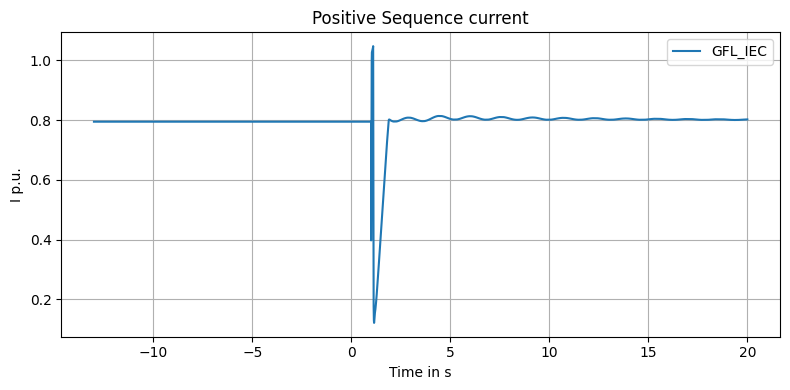

Positive Sequence current Maximum: 1.0477


In [61]:
tech = "GFL_IEC"
three_phsc = three_ph_scs[(tech,"E2_3PhSC")]
SMA_100 = to_10Hz_reporting_rate(three_phsc)
three_phsc_100 = to_10Hz_reporting_rate(three_phsc)
t1 = get_series(three_phsc,colmap,"t")
V1 = get_series(three_phsc,colmap,"V")
t2 = get_series(three_phsc_100,colmap,"t")
V2 = get_series(three_phsc_100,colmap,"V")
# plt.figure(figsize=(10,5))
# plt.plot(t1,V1,color = "blue", label = tech + " raw data")
# #plt.plot(t2, V2, color='red', label=tech + " 100ms sample")
# plt.xlim(0,20)
# plt.ylim(0,1.2)
# plt.xlabel("Time [s]")
# plt.title("Voltage")
# plt.ylabel("V")
# plt.legend()
# plt.grid(True)
# plt.show()

v_min = kpi_Vmin_fault(three_phsc,colmap)
Ts,Vss= kpi_V_recovery_time(three_phsc,colmap,1.1,0.98,0,2,20)
print(f"Min Voltage: {v_min}")
print(f"Recovery Voltage time: {Ts} with Vss: {Vss}")
plot_signal_from_df(three_phsc,colmap,"t","Ipos","Positive Sequence current","I p.u.",tech)
ipos = kpi_Ipos_max(three_phsc,colmap)
print(f"Positive Sequence current Maximum: {ipos}")

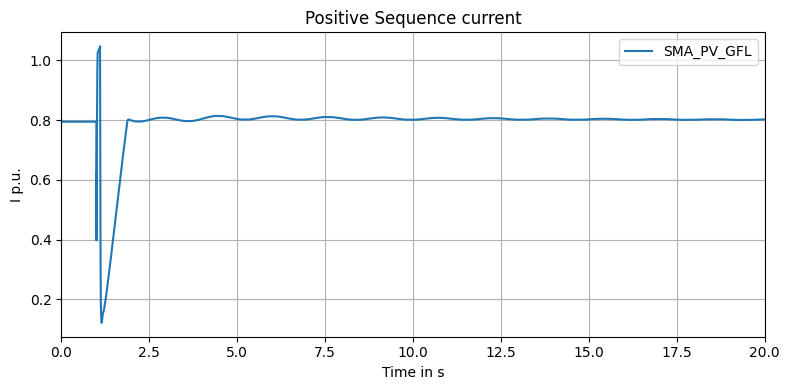

Positive Sequence current Maximum: 1.0477
(True, 0.8019075308230589, {'tail_start': 17.0, 'tail_end': 20.0, 'ripple_pu': 0.0033999999999999586, 'drift_pu': 0.0004016045303132376, 'ss_pu': 0.8019075308230589})


In [70]:
plot_signal_from_df(three_phsc,colmap,"t","Ipos","Positive Sequence current","I p.u.",tech)
ipos = kpi_Ipos_max(three_phsc,colmap)
print(f"Positive Sequence current Maximum: {ipos}")
print(get_ss_for_settling_time(three_phsc,colmap,"Ipos",20,3,0.01,0.002,"mean"))

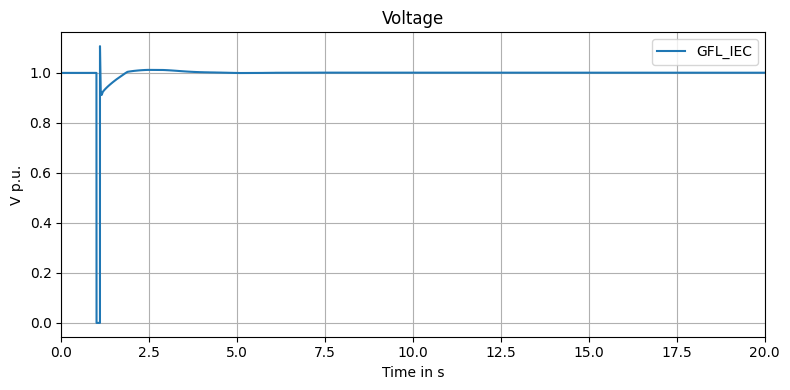

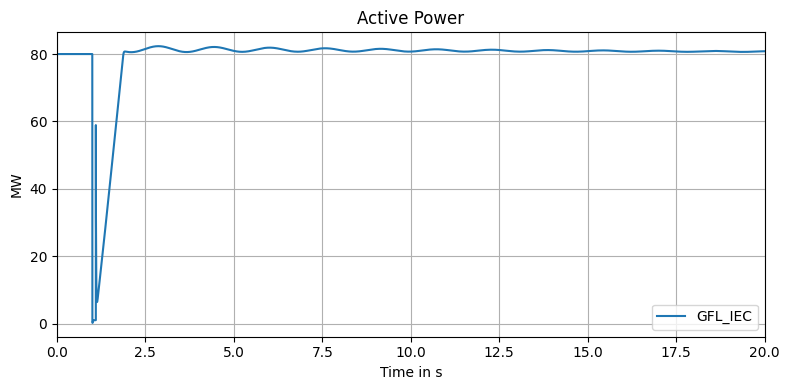

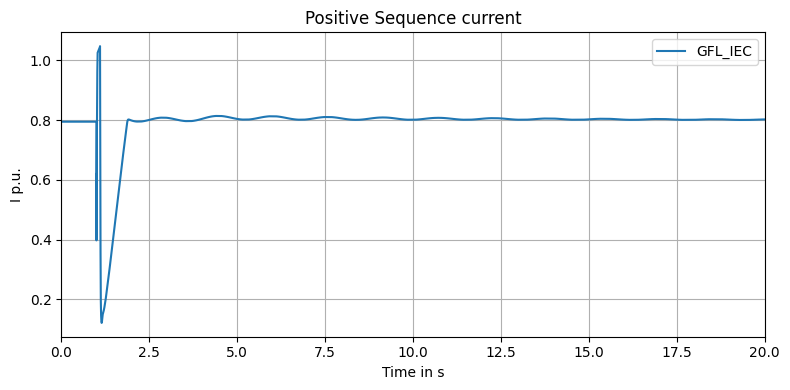

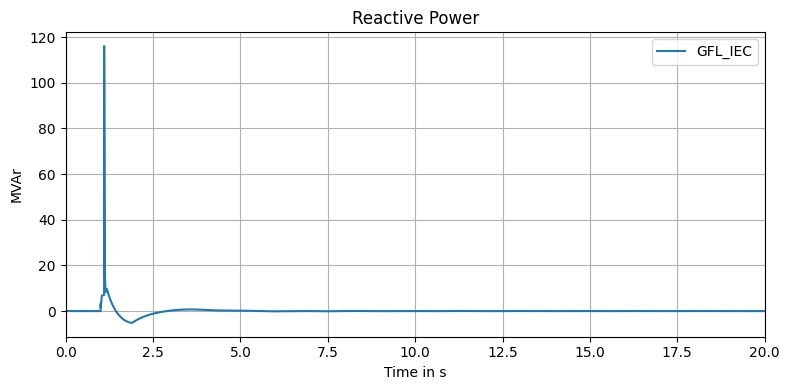

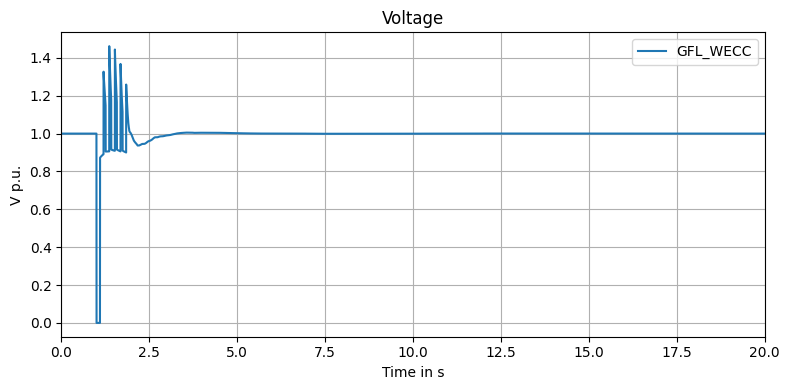

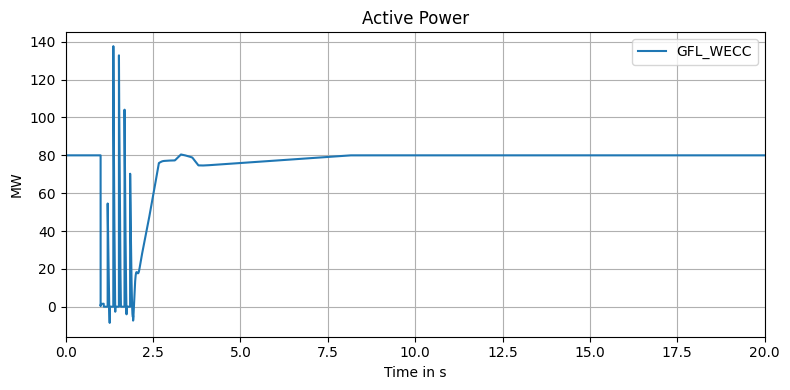

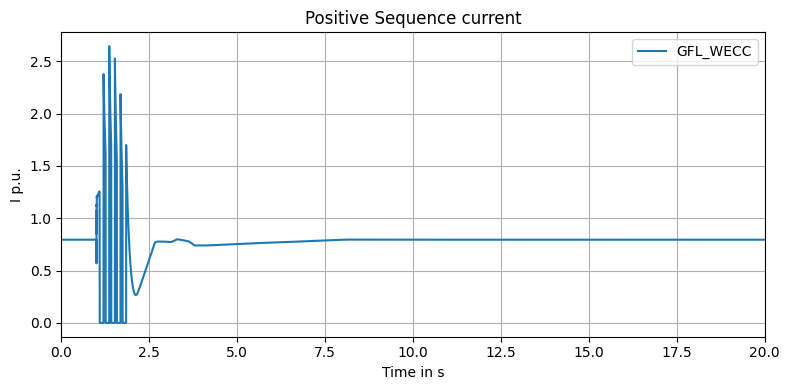

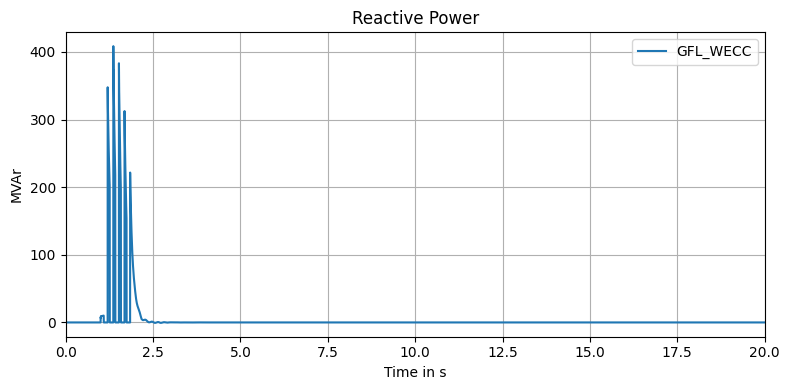

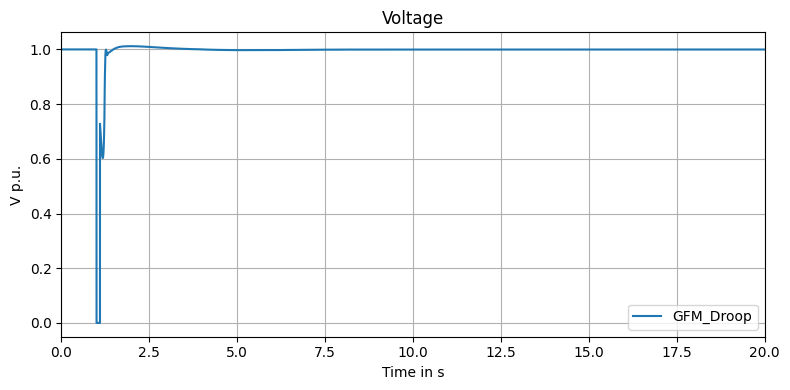

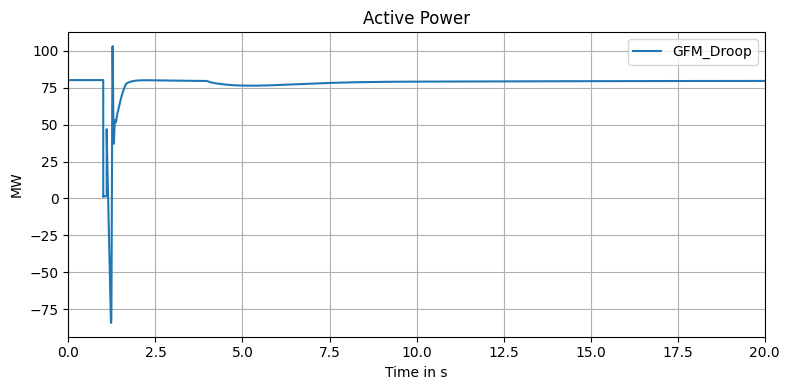

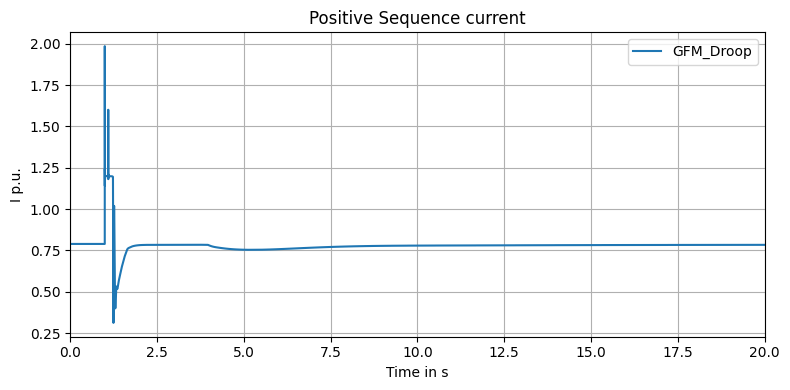

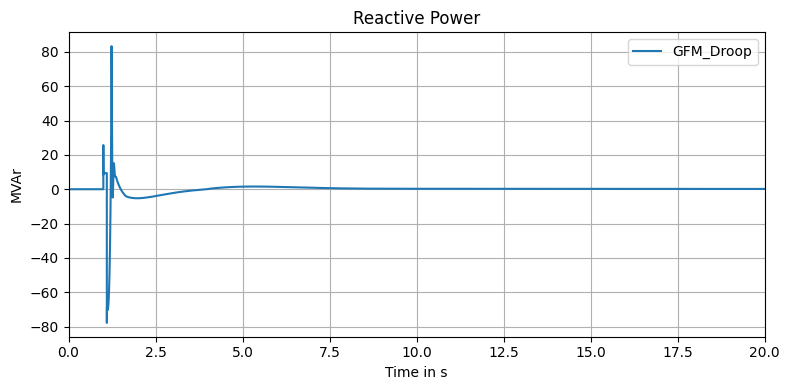

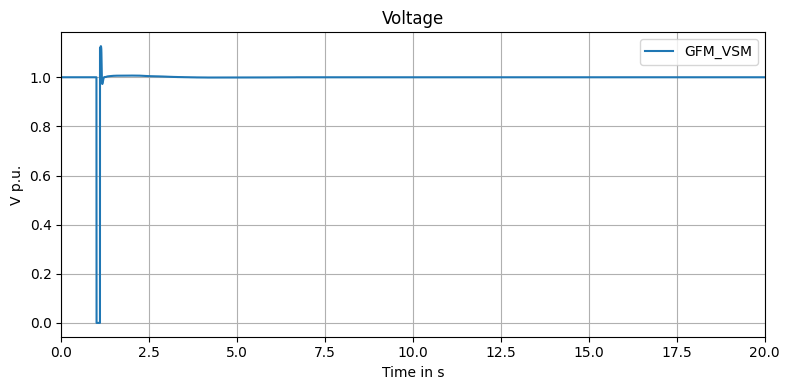

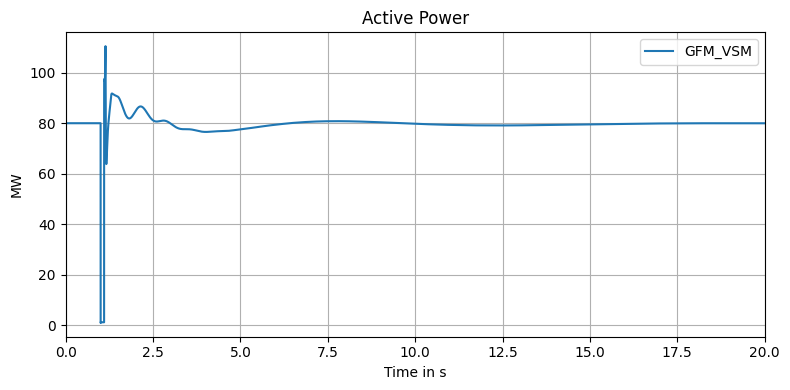

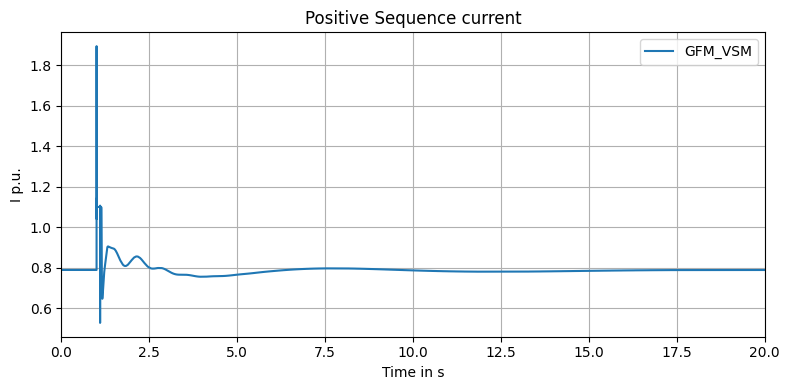

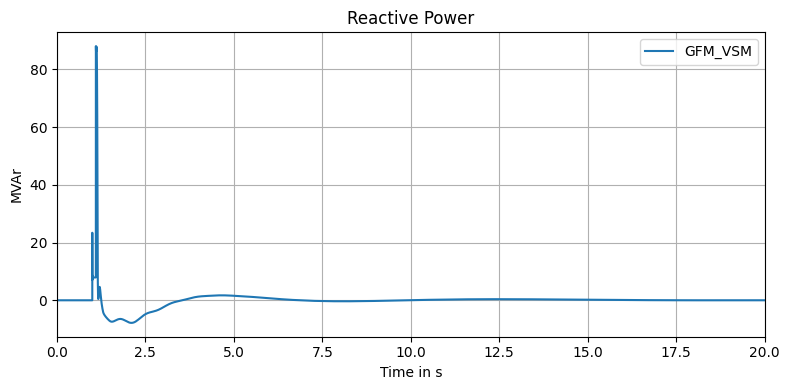

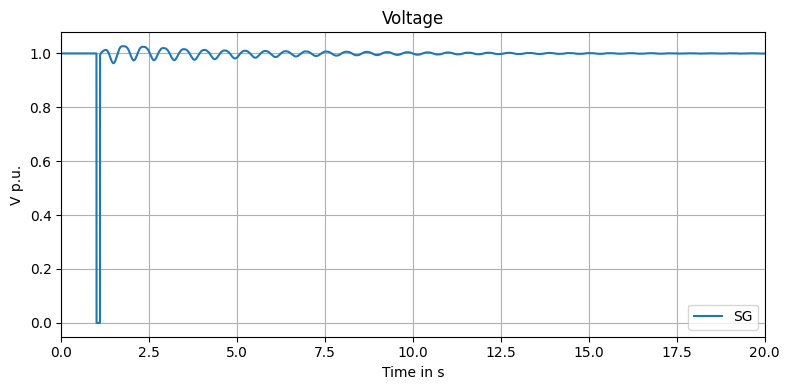

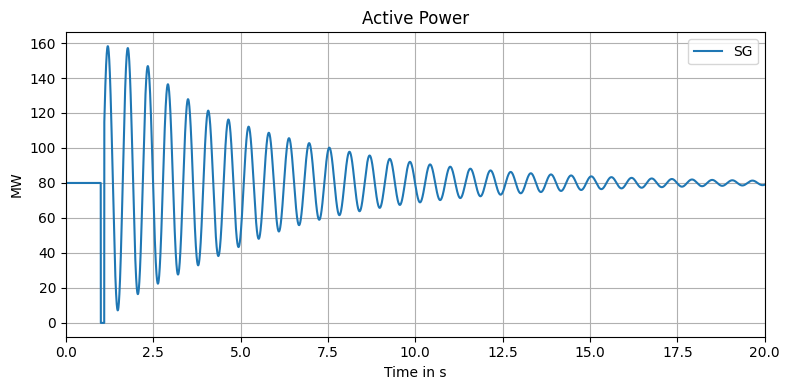

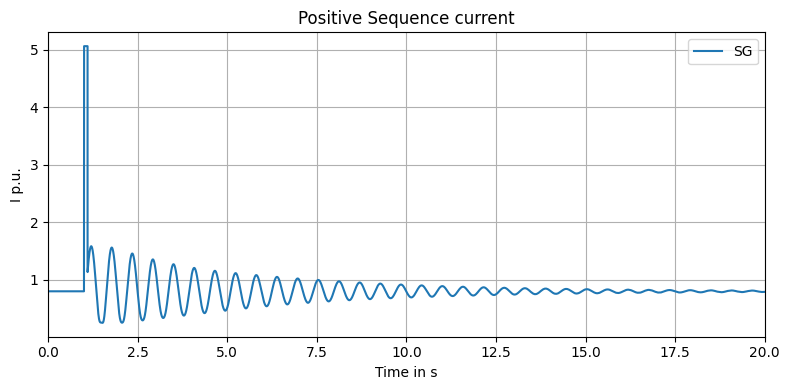

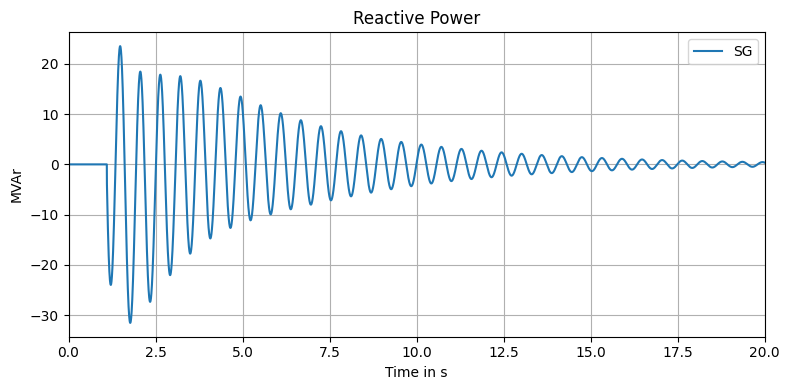

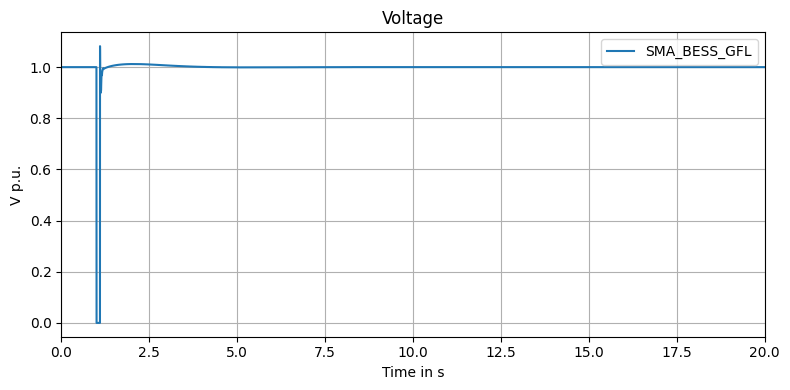

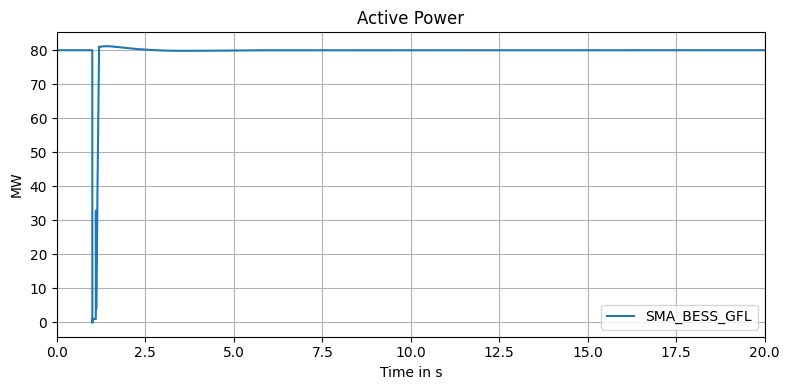

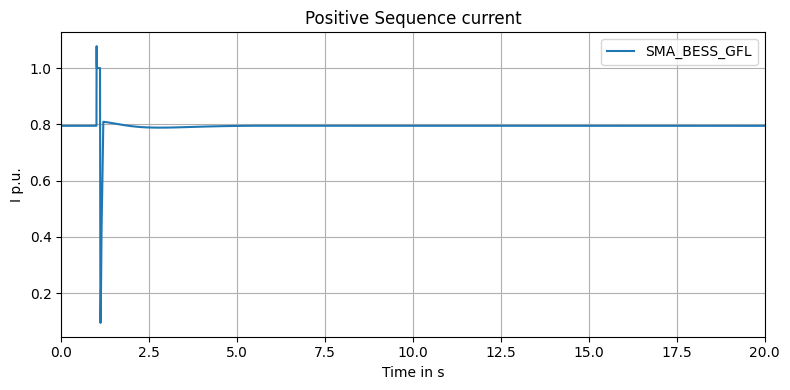

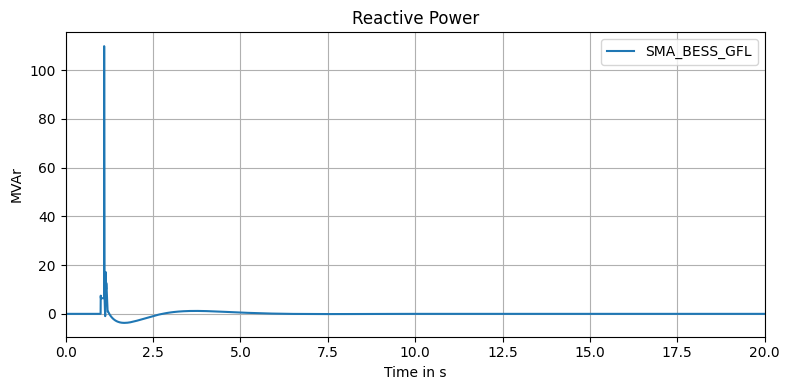

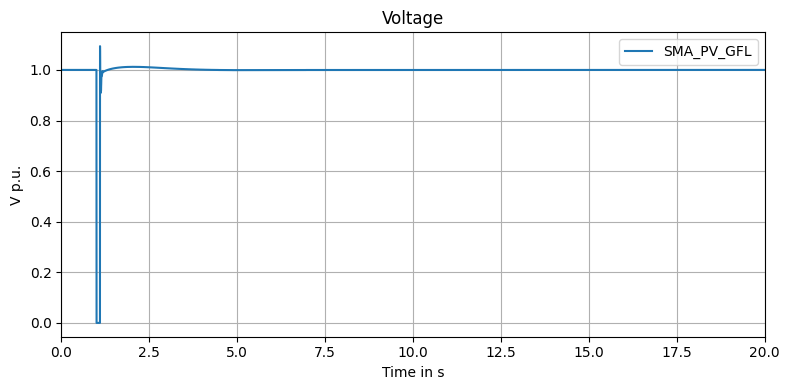

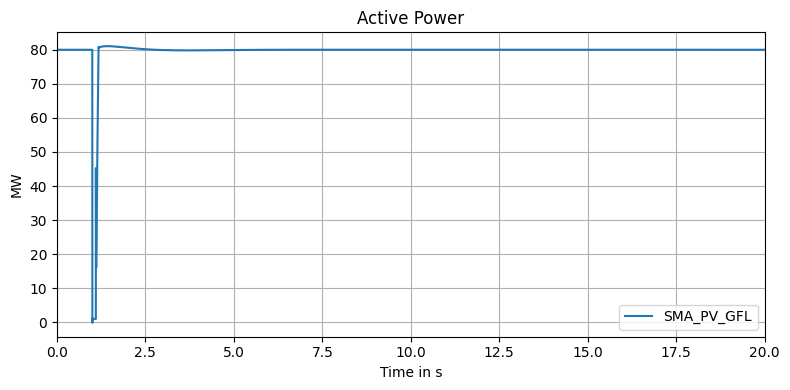

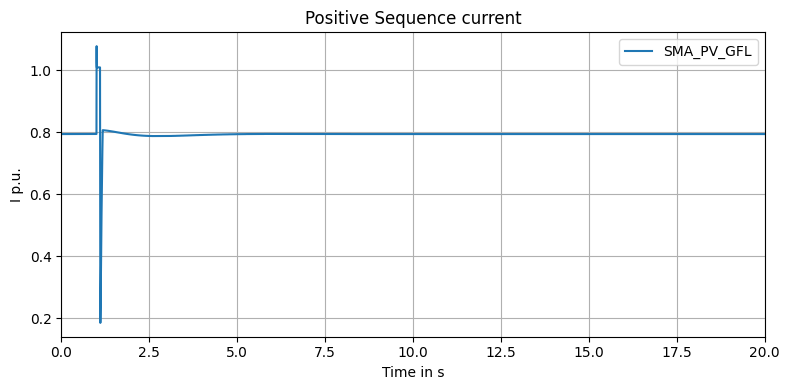

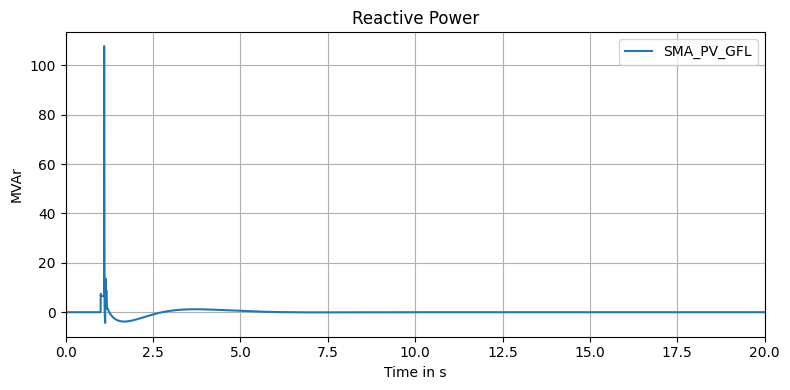

In [ ]:
for (tech,fault),df in three_ph_scs.items():
    plot_signal_from_df(df,colmap,"t","V","Voltage","V p.u.",tech)
    plot_signal_from_df(df,colmap,"t","P","Active Power","MW",tech)
    plot_signal_from_df(df,colmap,"t","Ipos","Positive Sequence current","I p.u.",tech)
    plot_signal_from_df(df,colmap,"t","Q","Reactive Power","MVAr",tech)

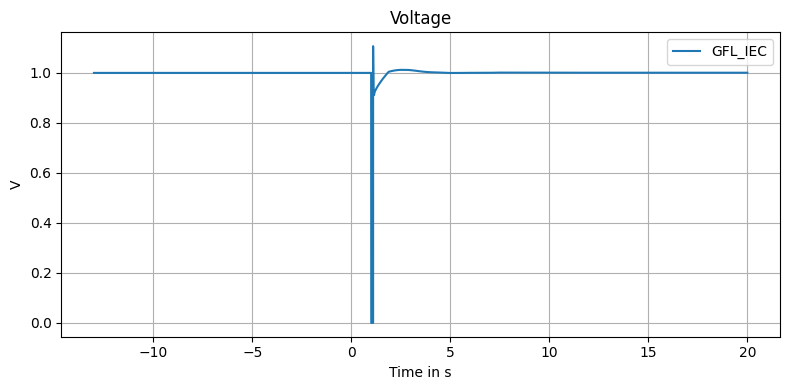

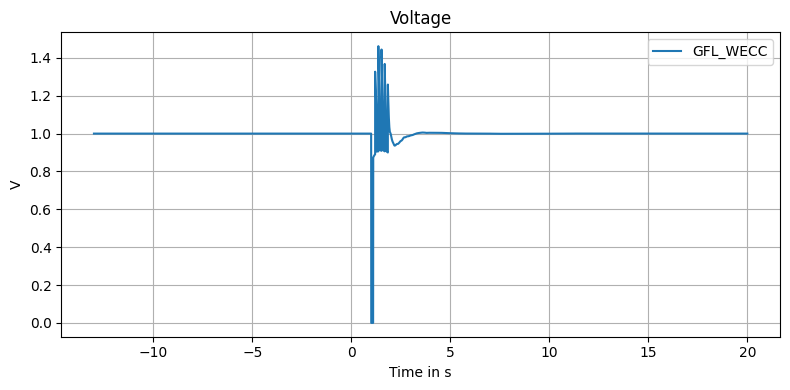

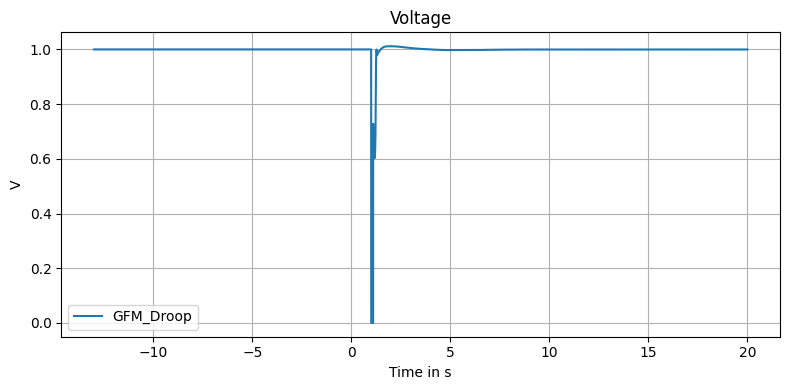

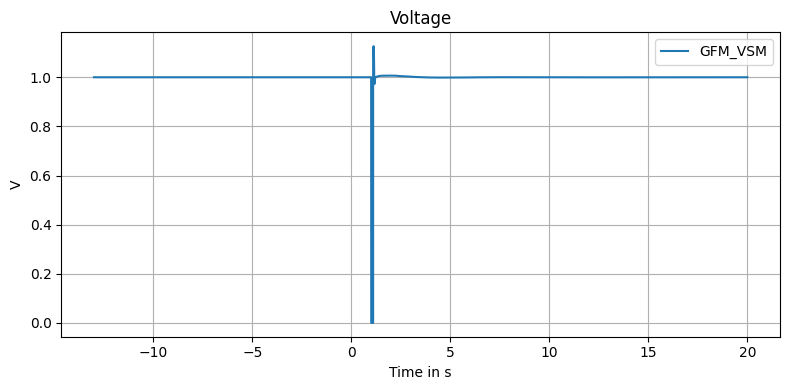

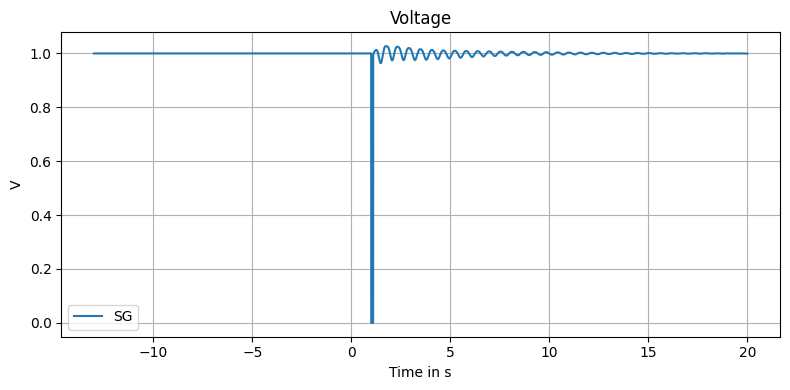

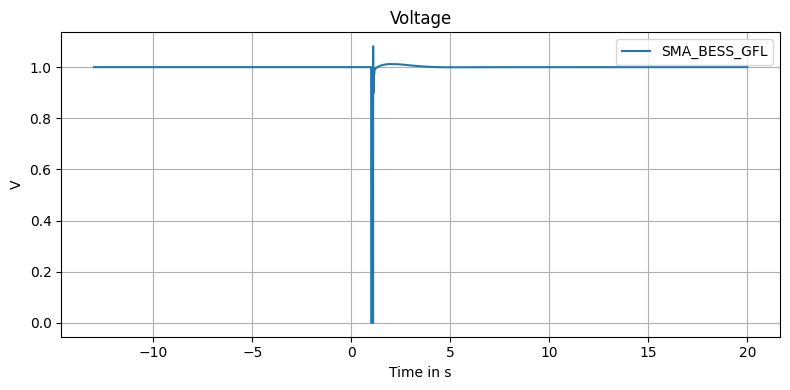

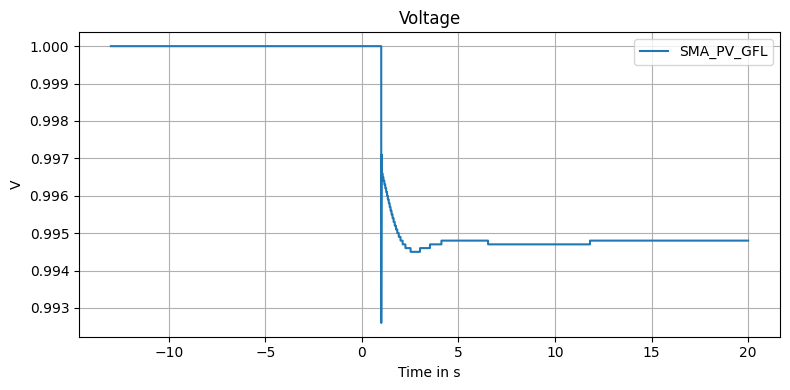

In [10]:
for (tech,fault),df in three_ph_scs.items():
    plot_signal_from_df(df,colmap,"t","V","Voltage","V",tech)


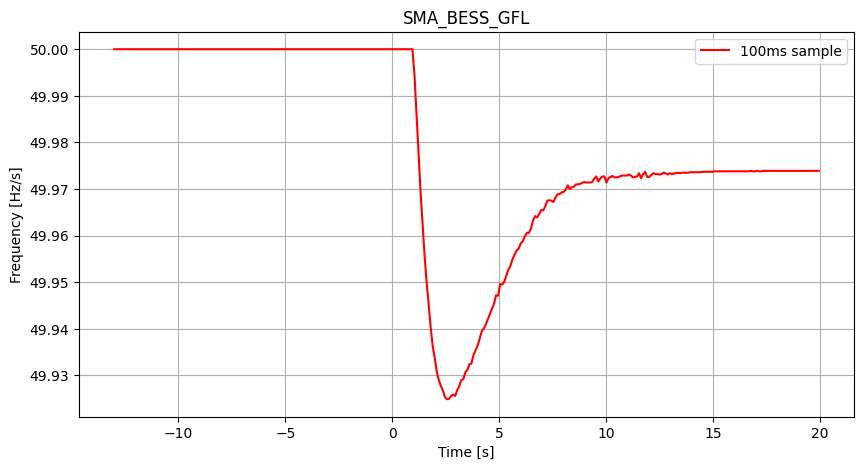

tt: [17.084  17.1788 17.2748 17.3709 17.467  17.5618 17.6578 17.7539 17.8503
 17.9458 18.0417 18.1378 18.2338 18.3288 18.4247 18.5208 18.6168 18.7118
 18.8077 18.9038 19.0002 19.0985 19.1938 19.2898 19.3859 19.482  19.5768
 19.6728 19.7689 19.865  19.9598] ff: [49.9739 49.9738 49.9738 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739]
Frequency band [49.96389354838709,49.98389354838709]


C:\Users\UI450907\AppData\Local\Temp\1\ipykernel_23440\1370631794.py:18: RuntimeWarning: invalid value encountered in divide
  rocof = np.diff(f)/np.diff(t)


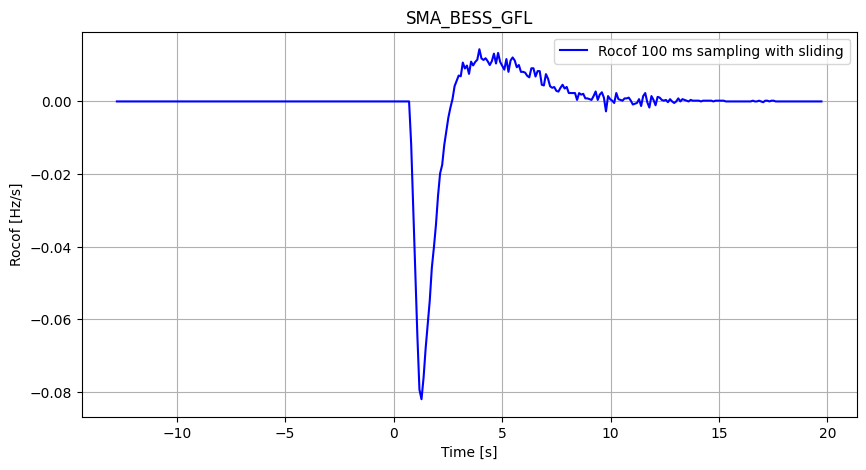

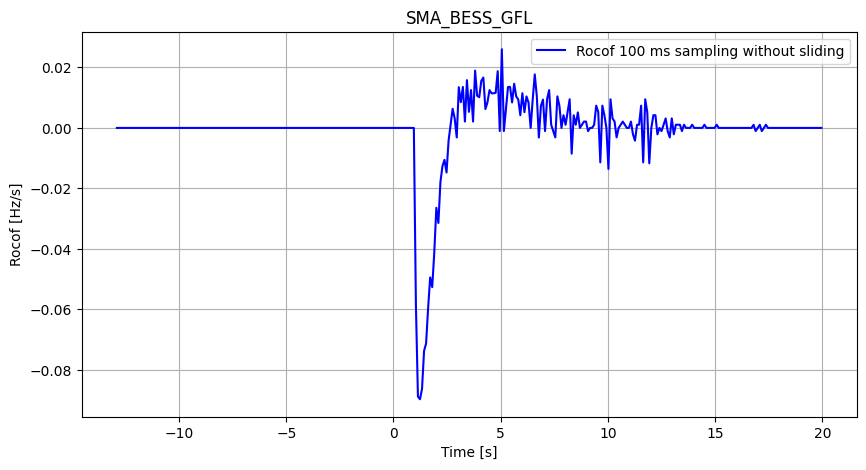

In [11]:
tech = "SMA_BESS_GFL"
loadstep = loadsteps[(tech,"E1_Load_Step")]
loadstep_100 = to_10Hz_reporting_rate(loadstep)
# f1 = get_series(loadstep,colmap,"f")
# t1 = get_series(loadstep,colmap,"t")
f2 = get_series(loadstep_100,colmap,"f")
t2 = get_series(loadstep_100,colmap,"t")
plt.figure(figsize=(10,5))
# plt.plot(t1,f1, color='blue', label="raw")
plt.plot(t2, f2, color='red', label="100ms sample")
plt.xlabel("Time [s]")
plt.title(tech)
plt.ylabel("Frequency [Hz/s]")
plt.legend()
plt.grid(True)
plt.show()
Ts,fss = kpi_f_setlting_time(loadstep_100,colmap,band=0.01,t_event=1)
#print(f"Ts: {Ts} and fss: {fss}")
nadir1 = kpi_f_nadir(loadstep_100,colmap,0,20)
nadir2= kpi_f_nadir(loadstep,colmap,0,20)
#print(f"nadir with 100 ms sampling: {nadir1}")
#print(f"nadir with raw data : {nadir2}")
overshoot1 = kpi_f_overshoot(loadstep_100,colmap,1,20)
overshoot2 = kpi_f_overshoot(loadstep,colmap,1,20)
#print(f"overshoot with 100 ms sampling: {overshoot1}")
#print(f"overshoot with raw data : {overshoot2}")
deltafss = kpi_delta_fss(fss)
#print(f"Delta Frequency: {deltafss} Hz" )
rocof1,dfdt1,trocof1= kpi_rocof_sliding(loadstep_100,colmap,window_s=0.5)
rocof2,dfdt2,trocof2 = kpi_rocof_sliding(loadstep,colmap)

rocof11,dfdt11,trocof11= kpi_rocof(loadstep_100,colmap)
rocof22,dfdt22,trocof22 = kpi_rocof(loadstep,colmap)
#PLOT 1
plt.figure(figsize=(10,5))
plt.plot(trocof1,dfdt1, color='blue', label="Rocof 100 ms sampling with sliding")
#plt.plot(trocof2,dfdt2, color='red', label="Rocof raw data")
plt.title(tech)
plt.xlabel("Time [s]")
plt.ylabel("Rocof [Hz/s]")
plt.legend()
plt.grid(True)
plt.show()

#PLOT2
plt.figure(figsize=(10,5))
plt.plot(trocof11,dfdt11, color='blue', label="Rocof 100 ms sampling without sliding")
#plt.plot(trocof22,dfdt22, color='red', label="Rocof raw data without sliding")
plt.title(tech)
plt.xlabel("Time [s]")
plt.ylabel("Rocof [Hz/s]")
plt.legend()
plt.grid(True)
plt.show()
# print(f"Rocof with 100 ms sampling with sliding: {rocof1}")
# #print(f"Rocof with raw data: {rocof2}")
# print(f"Rocof with 100 ms sampling without sliding: {rocof11}")
# #print(f"Rocof with raw data without sliding: {rocof2}")
P = get_series(loadstep_100,colmap,"P")
t = get_series(loadstep_100,colmap,"t")
#plot_signal(t,P,"Active Power","MW",tech)
deltaP,Pss,P0 = kpi_delta_P(loadstep,colmap,t_event=1)
P_max = kpi_P_max(loadstep_100,colmap,t_event=1,P0=P0)
#print(f"Delta P = {round(deltaP,3)} MW")
#print(f"P_max = {round(P_max,3)} MW")


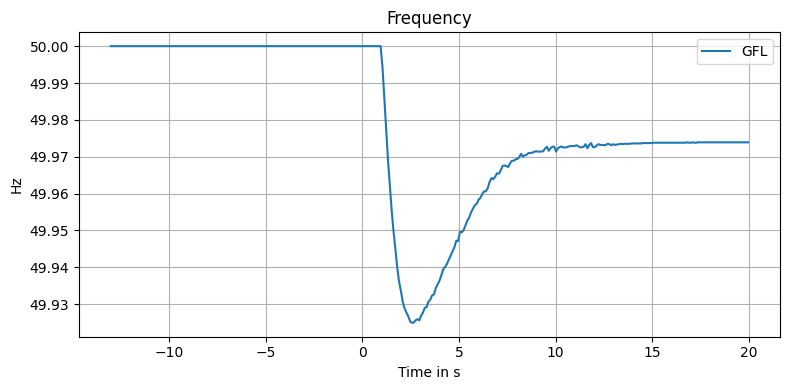

In [12]:
plot_signal_from_df(loadstep_100,colmap,"t","f","Frequency","Hz","GFL")

tt: [17.0982 17.1982 17.2982 17.3982 17.4982 17.5982 17.6982 17.7982 17.8982
 17.9982 18.0982 18.1982 18.2982 18.3982 18.4982 18.5982 18.6982 18.7982
 18.8982 18.9982 19.0982 19.1982 19.2982 19.3982 19.4982 19.5982 19.6982
 19.7982 19.8982 19.9982] ff: [49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739]
Frequency band [49.96389999999999,49.983899999999984]


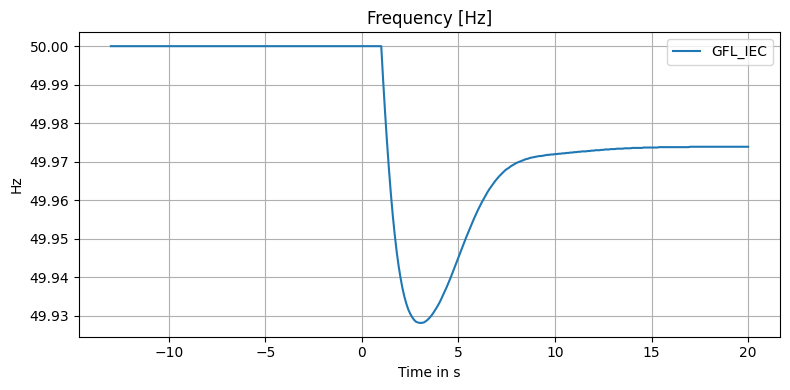

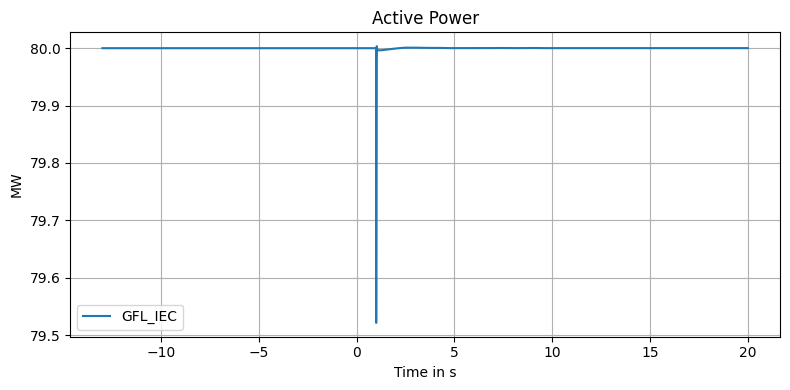

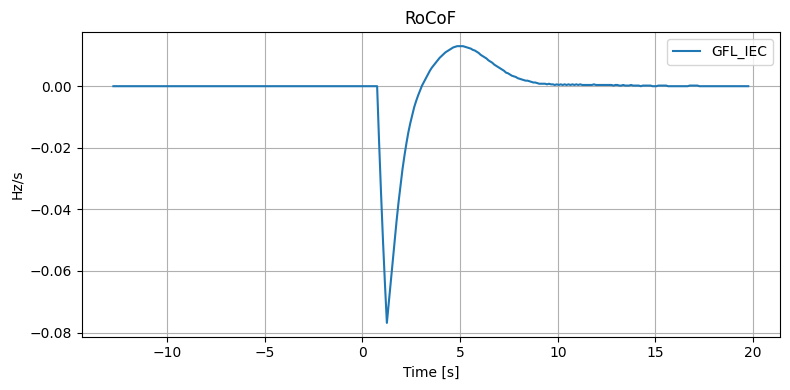

tt: [17.0955 17.1955 17.2955 17.3955 17.4955 17.5955 17.6955 17.7955 17.8955
 17.9955 18.0955 18.1955 18.2955 18.3955 18.4955 18.5955 18.6955 18.7955
 18.8955 18.9955 19.0955 19.1955 19.2955 19.3955 19.4955 19.5955 19.6955
 19.7955 19.8955 19.9955] ff: [49.9745 49.9745 49.9745 49.9745 49.9745 49.9745 49.9745 49.9745 49.9744
 49.9744 49.9744 49.9744 49.9744 49.9744 49.9744 49.9743 49.9743 49.9743
 49.9743 49.9743 49.9743 49.9743 49.9742 49.9742 49.9742 49.9742 49.9742
 49.9742 49.9742 49.9741]
Frequency band [49.96434666666668,49.984346666666674]


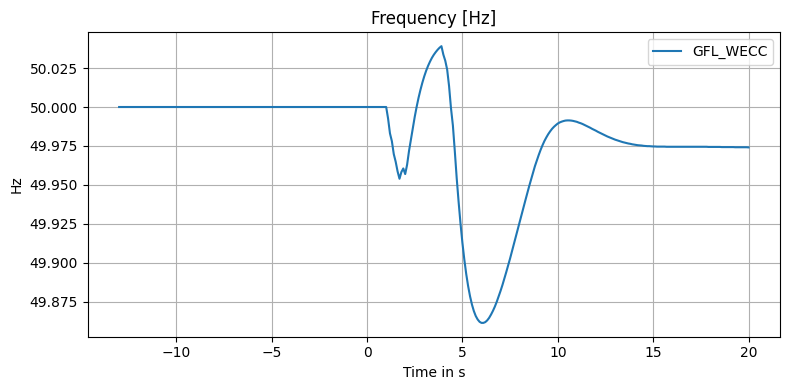

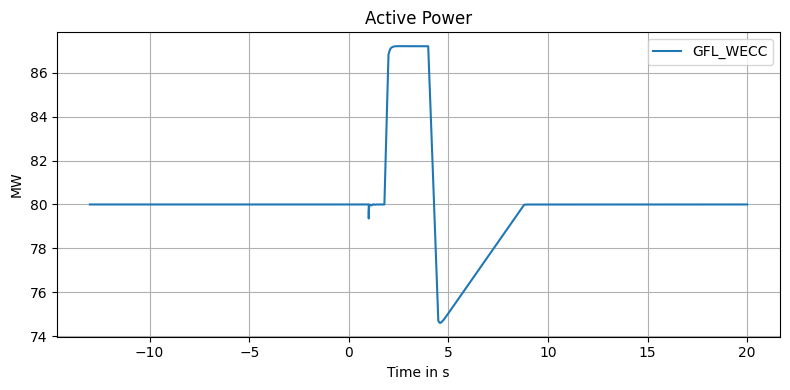

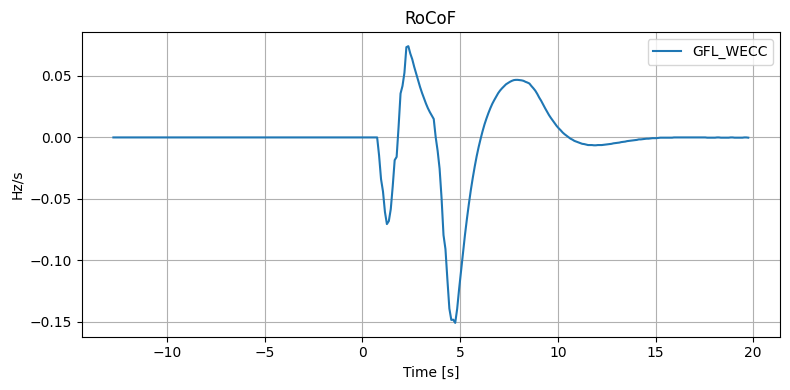

tt: [17.0982 17.1982 17.2982 17.3982 17.4982 17.5982 17.6982 17.7982 17.8982
 17.9982 18.0982 18.1982 18.2982 18.3982 18.4982 18.5982 18.6982 18.7982
 18.8982 18.9982 19.0982 19.1982 19.2982 19.3982 19.4982 19.5982 19.6982
 19.7982 19.8982 19.9982] ff: [49.9717 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717
 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717
 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717 49.9717
 49.9717 49.9717 49.9717]
Frequency band [49.961700000000015,49.98170000000001]


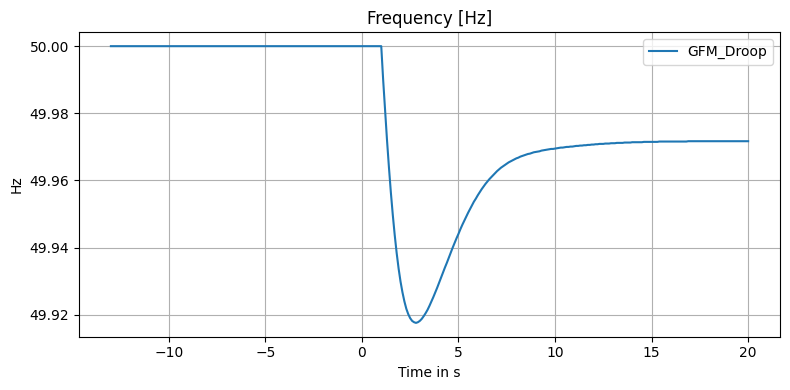

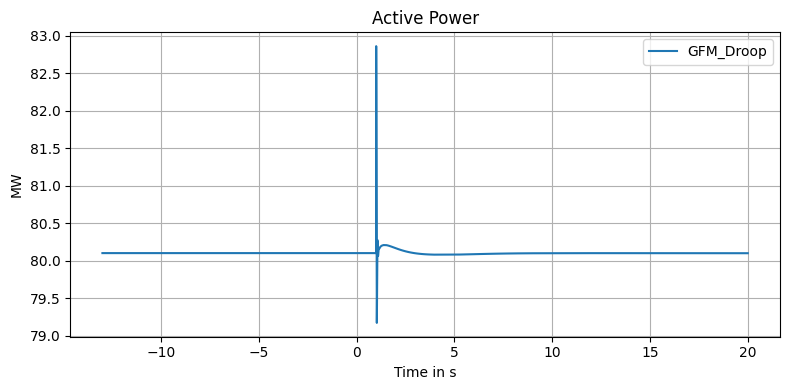

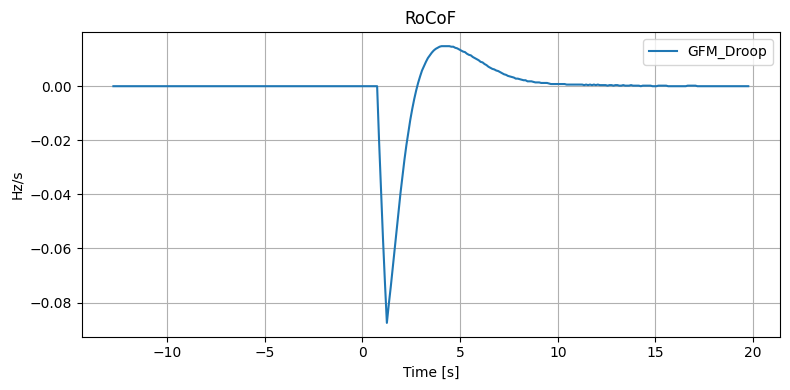

tt: [17.0982 17.1982 17.2982 17.3982 17.4982 17.5982 17.6982 17.7982 17.8982
 17.9982 18.0982 18.1982 18.2982 18.3982 18.4982 18.5982 18.6982 18.7982
 18.8982 18.9982 19.0982 19.1982 19.2982 19.3982 19.4982 19.5982 19.6982
 19.7982 19.8982 19.9982] ff: [49.9702 49.9703 49.9703 49.9704 49.9705 49.9706 49.9706 49.9707 49.9708
 49.9708 49.9709 49.9709 49.971  49.971  49.9711 49.9711 49.9712 49.9712
 49.9712 49.9712 49.9713 49.9713 49.9713 49.9713 49.9713 49.9713 49.9713
 49.9713 49.9713 49.9713]
Frequency band [49.96096666666665,49.980966666666646]


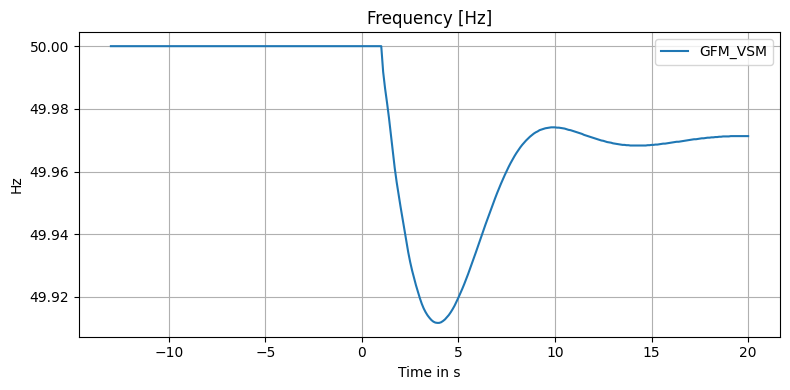

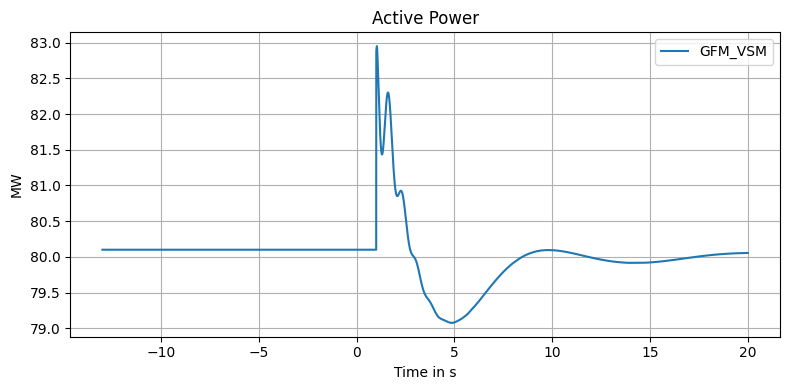

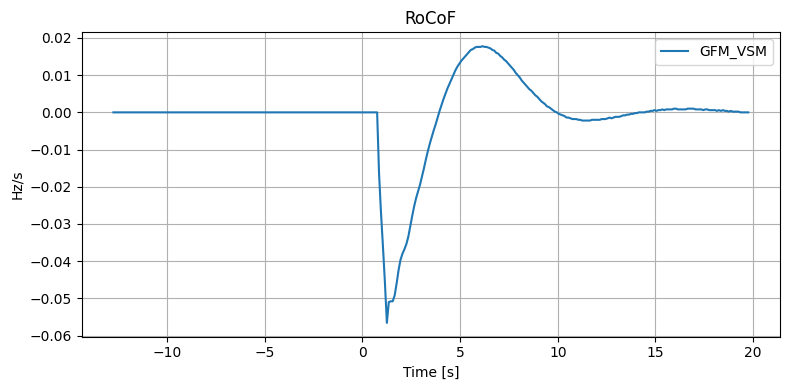

tt: [17.0982 17.1982 17.2982 17.3982 17.4982 17.5982 17.6982 17.7982 17.8982
 17.9982 18.0982 18.1982 18.2982 18.3982 18.4982 18.5982 18.6982 18.7982
 18.8982 18.9982 19.0982 19.1982 19.2982 19.3982 19.4982 19.5982 19.6982
 19.7982 19.8982 19.9982] ff: [49.9719 49.9718 49.9717 49.9718 49.9718 49.9719 49.9719 49.9718 49.9717
 49.9718 49.9719 49.9719 49.9719 49.9718 49.9718 49.9718 49.9719 49.9719
 49.9718 49.9718 49.9718 49.9718 49.9719 49.9719 49.9718 49.9718 49.9718
 49.9718 49.9719 49.9719]
Frequency band [49.961833333333345,49.98183333333334]


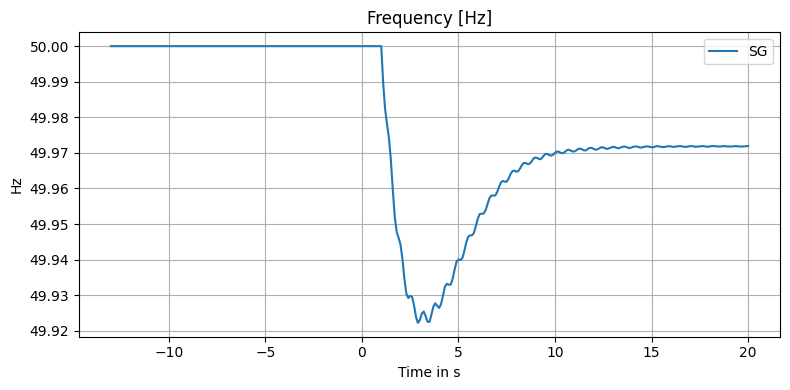

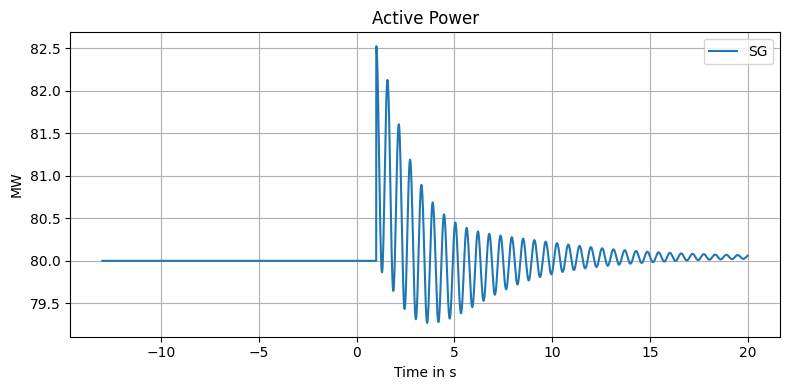

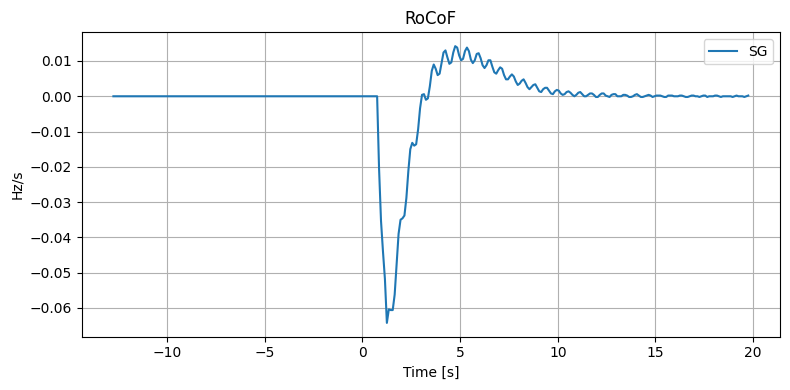

tt: [17.084  17.1788 17.2748 17.3709 17.467  17.5618 17.6578 17.7539 17.8503
 17.9458 18.0417 18.1378 18.2338 18.3288 18.4247 18.5208 18.6168 18.7118
 18.8077 18.9038 19.0002 19.0985 19.1938 19.2898 19.3859 19.482  19.5768
 19.6728 19.7689 19.865  19.9598] ff: [49.9739 49.9738 49.9738 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739]
Frequency band [49.96389354838709,49.98389354838709]


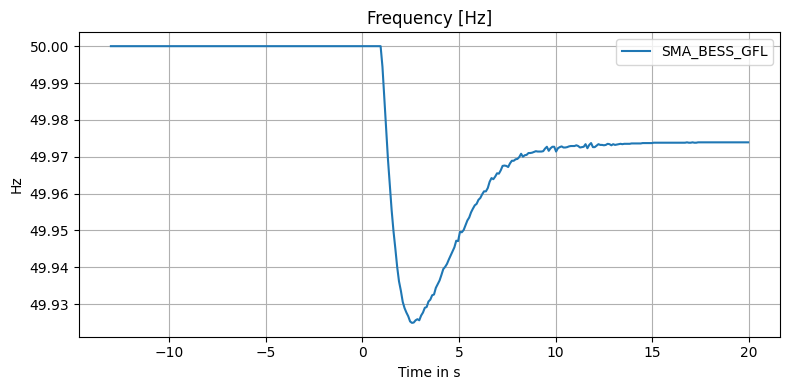

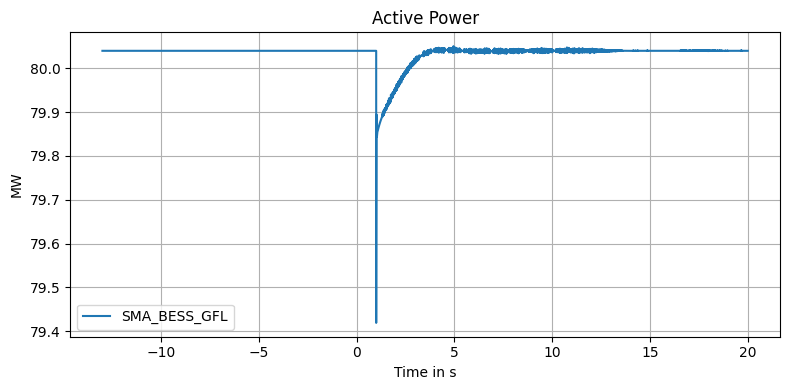

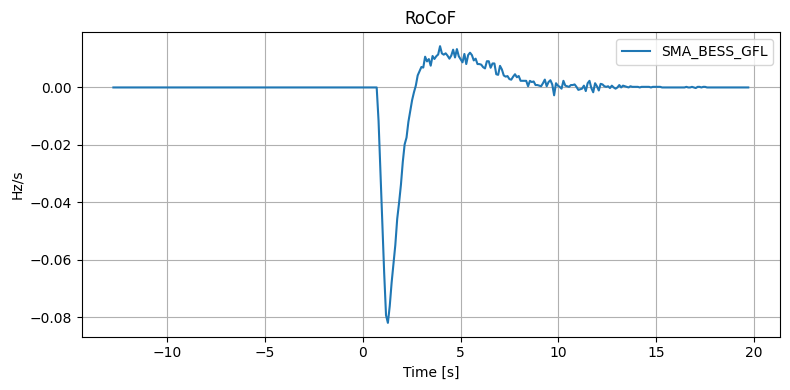

tt: [17.084  17.1788 17.2748 17.3709 17.467  17.5618 17.6578 17.7539 17.8503
 17.9458 18.0417 18.1378 18.2338 18.3288 18.4247 18.5208 18.6168 18.7118
 18.8077 18.9038 19.0002 19.0985 19.1938 19.2898 19.3859 19.482  19.5768
 19.6728 19.7689 19.865  19.9598] ff: [49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739 49.9739
 49.9739 49.9739 49.9739 49.9739]
Frequency band [49.96389999999999,49.983899999999984]


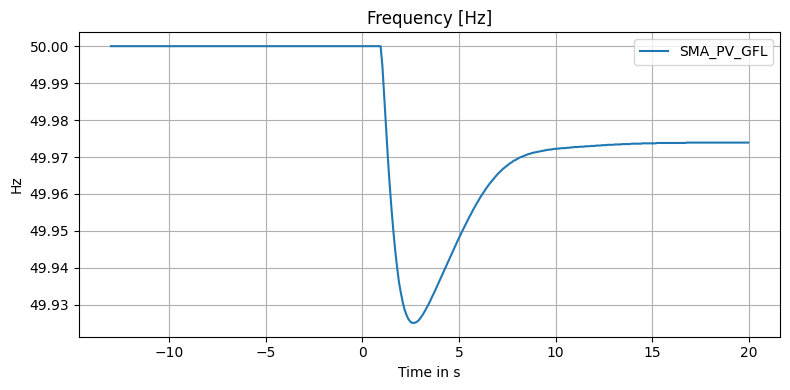

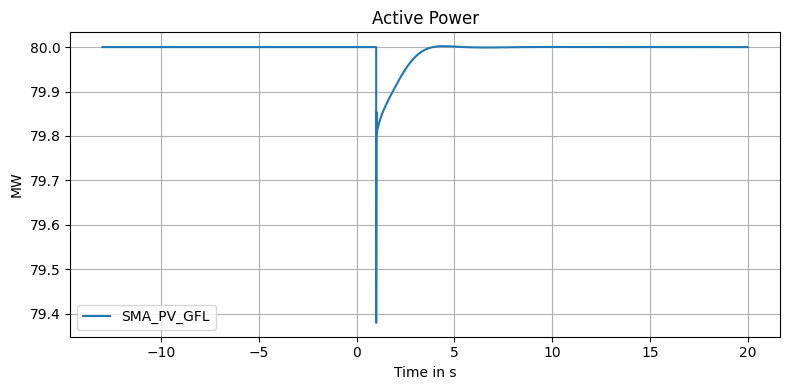

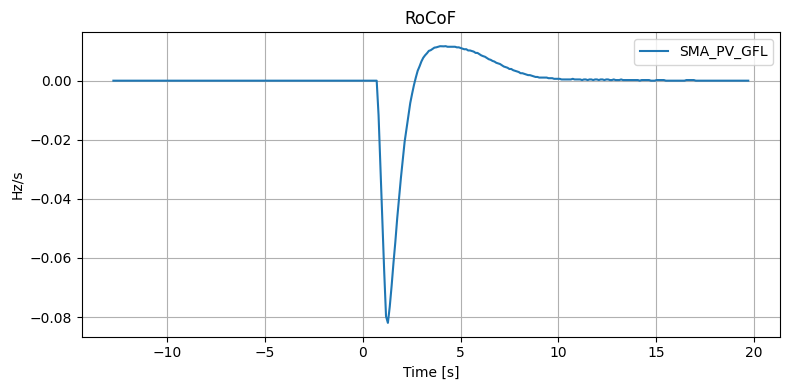

,Technology,f nadir [Hz],Rocof [Hz/s],Steady State frequency [Hz],f settling time [s],f max overshoot [Hz],delta f [Hz],Change in Active Power [MW],Max change in Active Power [MW]
0,GFL_IEC,49.9282,0.076877,49.973900,5.7982,50.000,-0.0261,0.000100,0.0010
1,GFL_WECC,49.8616,0.150792,49.974347,11.0955,50.039,-0.0257,0.000000,7.2027
2,GFM_Droop,49.9176,0.087515,49.971700,5.8982,50.000,-0.0283,-0.001087,0.1080
3,GFM_VSM,49.9117,0.056604,49.970967,6.5982,50.000,-0.0290,-0.069197,2.4400
4,SG,49.9222,0.064231,49.971833,6.2982,50.000,-0.0282,0.046130,2.0958


In [13]:
rows = []
for (technology,fault), df in loadsteps.items():
    df_100 = to_10Hz_reporting_rate(df)
    Ts,fss = kpi_f_setlting_time(df_100,colmap,band = 0.01,t_event=1)
    f_nadir = kpi_f_nadir(df_100,colmap,0,20)
    f_overshoot = kpi_f_overshoot(df_100,colmap,1,20)
    delta_fss = kpi_delta_fss(fss)
    rocof,dfdt,trocof = kpi_rocof_sliding(df_100,colmap,window_s= 0.5)
    deltaP,Pss,P0 = kpi_delta_P(df_100,colmap,t_event=1)
    P_max = kpi_P_max(df_100,colmap,t_event=1,P0 = P0)
    row = {"Technology" : technology, "f nadir [Hz]": f_nadir,
           "Rocof [Hz/s]":rocof,"Steady State frequency [Hz]":fss,
           "f settling time [s]": Ts, 
           "f max overshoot [Hz]":f_overshoot,"delta f [Hz]":delta_fss,
           "Change in Active Power [MW]": deltaP,"Max change in Active Power [MW]":P_max
           }
    rows.append(row)
    plot_signal_from_df(df_100,colmap,"t","f","Frequency [Hz]","Hz",technology)
    plot_signal_from_df(df,colmap,"t","P","Active Power","MW",technology)
    plot_signal(trocof,dfdt,"RoCoF","Hz/s",technology)
    
loadstep_analysis = pd.DataFrame(rows)
loadstep_analysis.head()

In [14]:
rows = []
for (technology,fault), df in three_ph_scs.items():
    Vdip = kpi_Vmin_fault(df,colmap,0.95,20)
    recovery_time = kpi_V_recovery_time(df,colmap,1.1,0.95,0.05,1,20)
    Ipos_max = kpi_Ipos_max(df,colmap,0,20)
    nadir = kpi_f_nadir(df,colmap,0,20)
    RoCoF,dfdt,t_rocof = kpi_rocof_max(df,colmap,0,5)


    row = {"Technology" : technology, "Voltage dip [V p.u.]": Vdip,
           "Recovery time [s]":recovery_time,"Max Positive Current": Ipos_max,
           "Frequency nadir [Hz]":nadir,"RoCoF [Hz/s]":RoCoF}
    rows.append(row)
    t = get_series(df,colmap,"t")
    V = get_series(df,colmap,"V")
    f= get_series(df,colmap,"f")
    #plot_signal(t,V,reference = 1,nadir = Vdip,band = 0.5,settling_time=recovery_time,
                #title="Voltage",y_label="Voltage [p.u.]")
    #plot_signal(t_rocof,dfdt,0,0,0,0,"RoCoF","Hz/s")

three_ph_sc_analysis = pd.DataFrame(rows)
three_ph_sc_analysis.head(7)


TypeError: kpi_Vmin_fault() takes 2 positional arguments but 4 were given

In [ ]:
print(
    loadstep_analysis.to_string(
        index=False,
        justify="center",
        float_format="{:.3f}".format
    )
)


In [ ]:
print(
    three_ph_sc_analysis.to_string(
        index=False,
        justify="center",
        float_format="{:.3f}".format
    )
)
